# Experiment: E13He – Capacitor Discharge with MOSFET Switching
## Yaman Ajaj (3722952) ;  Guilherme Schewtschik (3748052)

## Setup
In this experiment, we investigated the transient behavior of a capacitor discharging through a low-resistance path controlled by a MOSFET switch, using an Arduino Uno and Picoscope for control and measurement.
### Components used:
- Arduino Uno (3.3 V logic)
- Maker-Factory IRF520 MOSFET switch module
- Capacitor
- Resistors
- Breadboard and jumper wires
- Picoscope 2204A with PicoScope 6 software
### Circuit Description:
The circuit was built as follows:
- The capacitor is charged through a 1 kΩ resistor from Arduino’s 3.3 V output.
- A MOSFET switch (IRF520) is connected such that its drain (V–) is wired to the negative terminal of the capacitor through a discharge resistor.
- Gate (Vin) is controlled by Arduino pin D2, and source (GND) is connected to common ground.
- The Picoscope measures the voltage across the capacitor to observe discharge behavior.

The Arduino was programmed to periodically switch the MOSFET on/off, allowing the capacitor to charge and discharge. The Picoscope captures the voltage across the capacitor during these cycles.

![Circuit](firstSetup.jpg)

![ResCircuit](closeup.jpg)

### Measurement Technique:
The Picoscope was configured in:
- Single trigger mode
- Falling edge trigger on Channel A
- Appropriate time base (10 µs/div)
- Voltage range set to $\pm 10$ V

## Theoretical Background:
When a charged capacitor is discharged through a resistor, the voltage across it follows an exponential decay governed by the differential equation:
$$V(t) = V_0 e^{-\frac{t}{RC}}$$
where:
- $V(t) $ is the voltage across the capacitor at time $t$,
- $V_0$ is the initial voltage (3,3 V)
- $R$ is the resistance in the discharge path (1 kΩ)
- $C$ is the capacitance of the capacitor
- $\tau = RC$ is the time constant of the circuit.

## Data analysis:
We performed measurements for three different Resistors values ($1K \Omega , 100 \Omega , 22 K\Omega, 100 G \Omega$). The data was exported from PicoScope as CSV files and analyzed using Python.

### Task 1: Initial Measurement

We performed a first measurement using a 1 nF capacitor, and then a 220 nF capacitor, discharged through a low resistance path via the MOSFET. The Picoscope recorded the voltage drop across the capacitor in “Single” trigger mode.

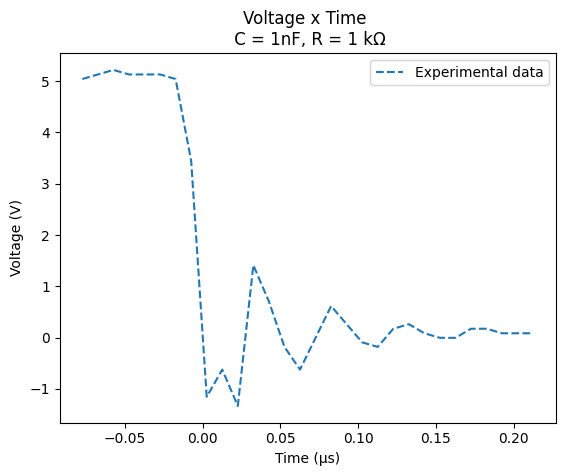

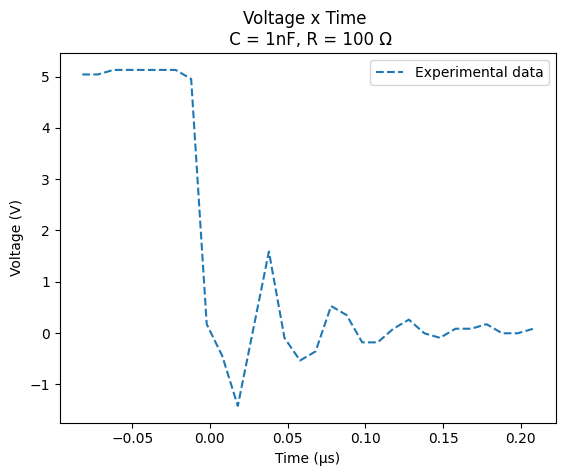

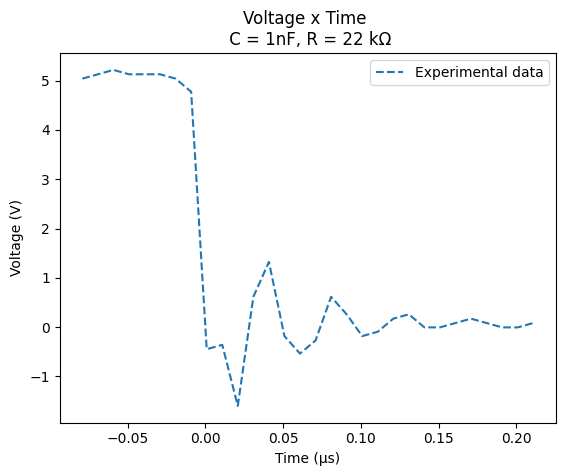

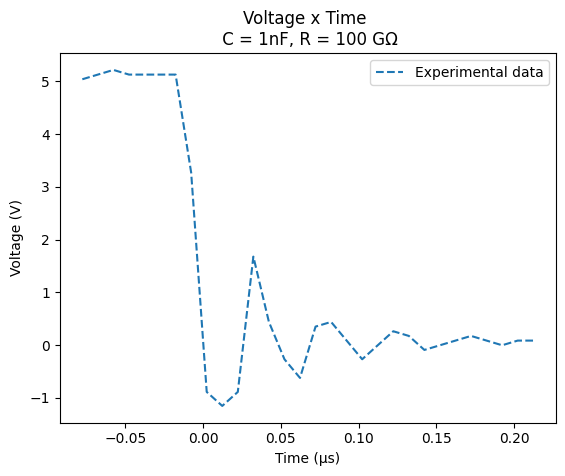

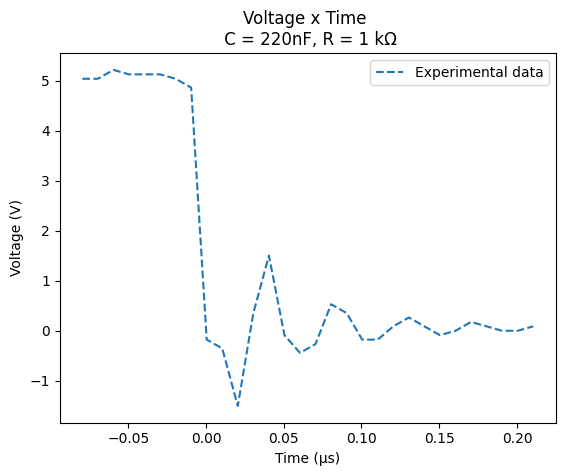

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

#description of each experiment
names = ['C = 1nF, R = 1 kΩ', 'C = 1nF, R = 100 Ω', 'C = 1nF, R = 22 kΩ','C = 1nF, R = 100 GΩ','C = 220nF, R = 1 kΩ']

#data import
data1 = pd.read_csv('wave1.csv', sep=';')
V1 = data1['(V)'].to_numpy()
t1 = data1['(us)'].to_numpy()

data2 = pd.read_csv('wave2.csv', sep=';')
V2 = data2['(V)'].to_numpy()
t2 = data2['(us)'].to_numpy()

data3 = pd.read_csv('wave3.csv', sep=';')
V3 = data3['(V)'].to_numpy()
t3 = data3['(us)'].to_numpy()

data4 = pd.read_csv('wave4.csv', sep=';')
V4 = data4['(V)'].to_numpy()
t4 = data4['(us)'].to_numpy()

data5 = pd.read_csv('wave5.csv', sep=';')
V5 = data5['(V)'].to_numpy()
t5 = data5['(us)'].to_numpy()

#organizing the data 
V = np.array([V1,V2,V3,V4,V5])
t = np.array([t1,t2,t3,t4,t5])

#difference between each element of V
dV = np.diff(V)

V_ind = np.array([])
t_ind = np.array([])

for i in range(0,5):    
    #creating a mask aroun the voltage shift
    index_max_v = np.nonzero(dV[i] == max(dV[i]))[0]
    index_around_max = np.arange(index_max_v[0]-10, index_max_v[0]+20)

    V_ind = np.append(V_ind, [V[i][index_around_max]])
    t_ind = np.append(t_ind, [t[i][index_around_max]])

#reshaping the arrays
V_ind = V_ind.reshape(5,30)
t_ind = t_ind.reshape(5,30)

for i in range(0,5):
    plt.figure(f'Measurement {i+1}')
    plt.title(f'Voltage x Time \n {names[i]}')
    plt.xlabel('Time (µs)')
    plt.ylabel('Voltage (V)')

    plt.plot(t_ind[i], V_ind[i], '--', label = 'Experimental data')
        
    plt.legend(loc = 'upper right')

plt.show()

### Task 2: Model Development

We developed a model based on the first-order linear differential equation:
$$\frac{dV}{dt} = -\frac{1}{RC} V \rightarrow V(t) = V_0 e^{-\frac{t}{RC}}$$

We validated this model by fitting the exponential function to our data using Python's curve_fit() method from scipy.optimize.

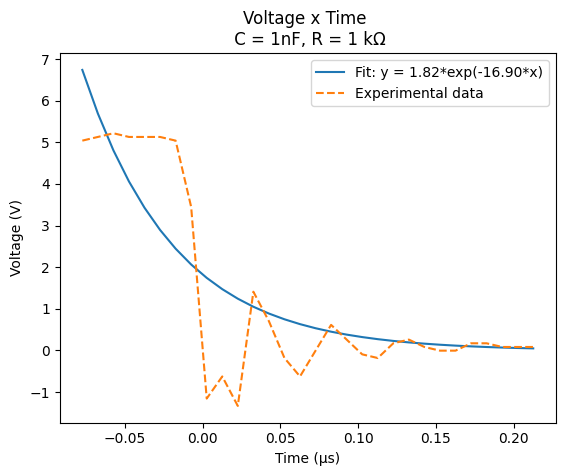

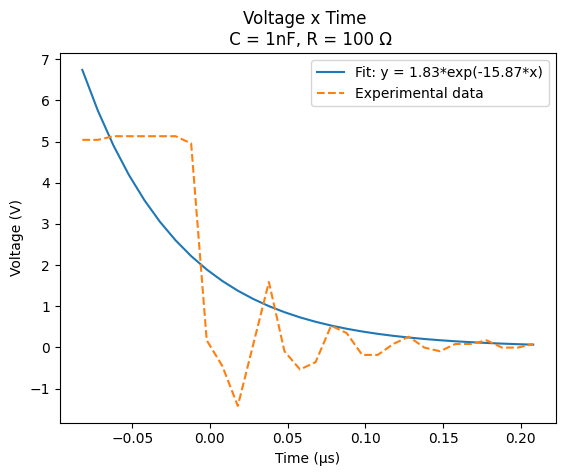

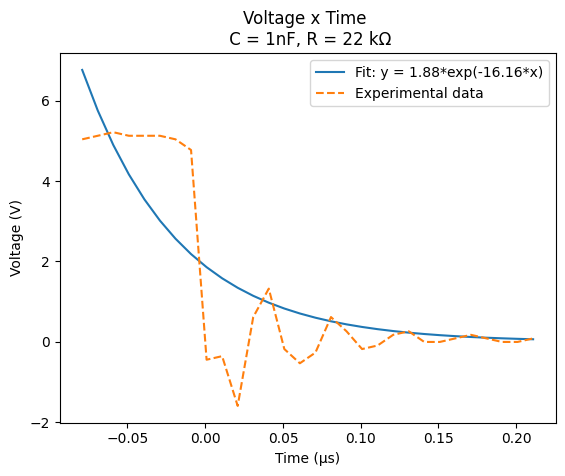

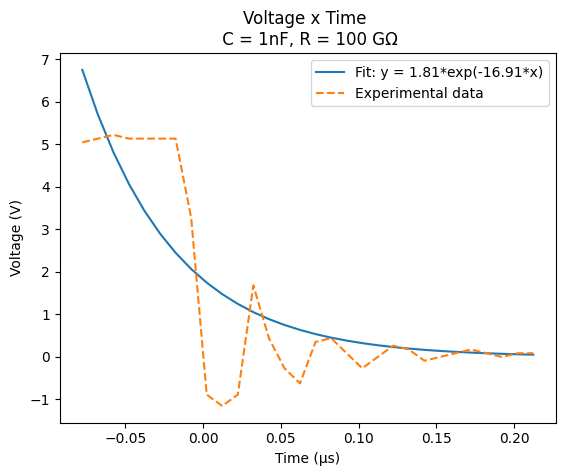

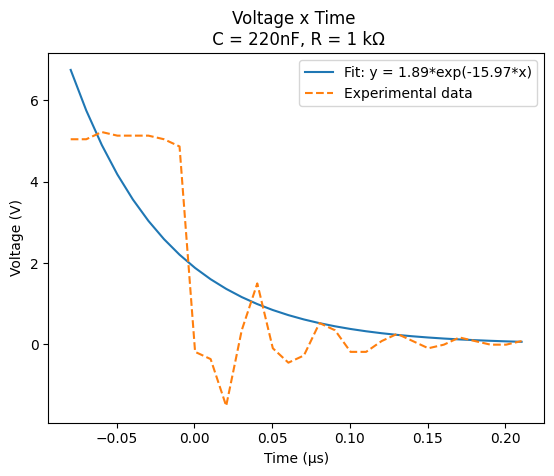

In [ ]:
V_calc = np.array([])

popt = np.array([])

#curve for fitting
def exp(x,A,b):
    return A*np.exp(x*b)

#calculating the fit for each experiment
for i in range(0,5):    
    x,_ = curve_fit(exp, t_ind[i] ,V_ind[i])
    popt = np.append(popt, x)
    V_calc = np.append(V_calc, exp(t_ind[i], x[0], x[1]))

#fit coeficients
popt = popt.reshape(5,2)

#reshaping the array
V_calc = V_calc.reshape(5,30)

#generating the graphs
for i in range(0,5):
    plt.figure(f'Fit {i+1}')
    plt.title(f'Voltage x Time \n {names[i]}')
    plt.xlabel('Time (µs)')
    plt.ylabel('Voltage (V)')

    plt.plot(t_ind[i], V_calc[i] , '-', label = f'Fit: y = {"%.2f"%(popt[i,0])}*exp({"%.2f"%(popt[i,1])}*x)')
    plt.plot(t_ind[i], V_ind[i], '--', label = 'Experimental data')
        
    plt.legend(loc = 'upper right')

plt.show()

### Observations:
- All curves show a clear exponential decay.
- Fitted time constants agree with $\tau = RC$ within experimental error.
- This confirms the model's predictive power for varying capacitances and resistances.